# GraphTCN weather evaluation

This notebook reads the completed fixed-architecture weather artifacts from the local Google Drive folder. It does not construct models or rerun inference. The five sections provide:

1. central-node test metric tables;
2. central-node final-horizon forecast plots;
3. learned adjacency matrices with their training-only correlation priors;
4. learned $\alpha$ and $\beta$ values for every final GraphTCN run;
5. central-to-neighbour T850 correlations over the relevant training split.


In [1]:
# Cell 1 — all imports and local repository discovery
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root from the VS Code notebook working directory."""
    start = (start or Path.cwd()).resolve()
    candidates = (start, *start.parents)

    for candidate in candidates:
        if (
            (candidate / "src" / "evaluation" / "weather_evaluation.py").is_file()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the dynamic_graphs_thesis repository root. "
        "Open this notebook from inside the repository in VS Code, then rerun the cell."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.weather_evaluation import (
    plot_central_neighbour_t850_correlations,
    plot_weather_forecasts,
    plot_weather_graph,
    show_weather_alpha_beta_table,
    show_weather_results,
)

print("Repository root:", PROJECT_ROOT)


Repository root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis


In [3]:
# Cell 2 — local path to the completed weather artifacts
# This is the only shared path in the notebook. City, year, horizon,
# graph component, and window choices are passed directly in each function call.
WEATHER_ROOT = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/weather"
)

if not WEATHER_ROOT.is_dir():
    raise FileNotFoundError(
        "Weather artifact root not found. Update WEATHER_ROOT in this cell if "
        f"your Google Drive is mounted elsewhere:\n{WEATHER_ROOT}"
    )

print("Weather artifact root:", WEATHER_ROOT)


Weather artifact root: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/weather


## 1. Central-node test results

`show_weather_results` displays the three headline Sonnet-style metrics at the central grid point and final forecast position:

- linear correlation, $r$;
- mean absolute error, MAE;
- weather-adjusted sMAPE, $\epsilon\%$.

Each selector accepts a specific value or `None`. For example, `city=None`, `test_year=2016`, and `horizon=None` displays every city and every horizon for the 2016 test split. When all test years are selected, an arithmetic `Average` column is included.


In [4]:
# Inputs:
# - city: one city name, or None for all five cities.
# - test_year: 2016, 2017, 2018, or None for all three test years.
# - horizon: 4, 12, 28, 120, or None for all four horizons.
result_tables = show_weather_results(
    weather_root=WEATHER_ROOT,
    city=None,
    test_year=None,
    horizon=None,
)


## 2. Final-horizon forecast series

For each rolling sample, the plotted prediction is the final point $\widehat{y}_{t+H}$ and the black line is the corresponding observed central-grid T850 value $y_{t+H}$. Because the dataset window stride is one six-hour observation, the final-horizon forecasts form a dense six-hourly series.

The three independently retrained test-year forecasts are colour-coded, while the observed series is shown in black across the complete selected period.


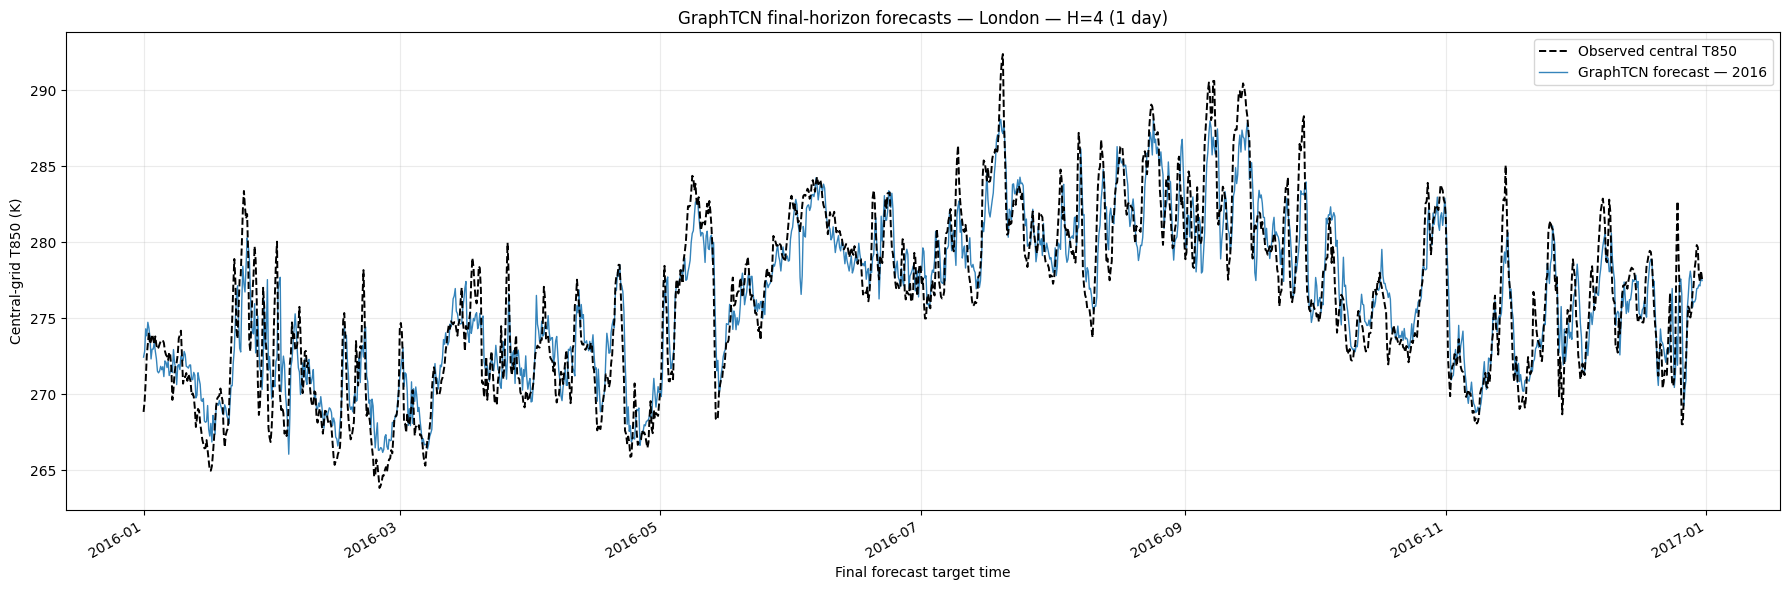

In [25]:
# Inputs:
# - city: city whose central-grid T850 series is plotted.
# - horizon: final forecast position H in {4, 12, 28, 120}.
# - test_years: any ordered subset of (2016, 2017, 2018).
forecast_values, forecast_figure, forecast_axis = plot_weather_forecasts(
    weather_root=WEATHER_ROOT,
    city="london",
    horizon=4,
    test_years=[2016],
    figsize=(18, 6),
)

plt.show()


## 3. Learned weather graphs

The saved learned graph is the final-context adjacency used for forecasting. Rows are target nodes and columns are source nodes:

$$
A_{ij}=\text{weight from source node }j\text{ to target node }i.
$$

`plot_weather_graph` follows the same selection convention as Graph Hub. `day` refers to the **forecast-origin date**, and `window` is a **one-based** position within that date:

- `day=None, window=None`: average all saved test graphs;
- `day="YYYY-MM-DD", window=None`: average all windows on that day;
- `day=None, window=n`: average window `n` across all days;
- `day="YYYY-MM-DD", window=n`: plot one exact window-level graph.

One call produces three **independent figures**, each with its own white-to-red colour scale:

1. the chosen learned graph component (`"selected"`, `"dynamic"`, or `"base"`);
2. the row-normalised correlation graph prior supplied to the model;
3. the symmetric absolute $\Delta T850$ correlation matrix over the corresponding training split, before row normalisation.

The `day` and `window` inputs affect only the learned graph. The two correlation matrices are fixed for the supplied city, horizon, and test-year model.


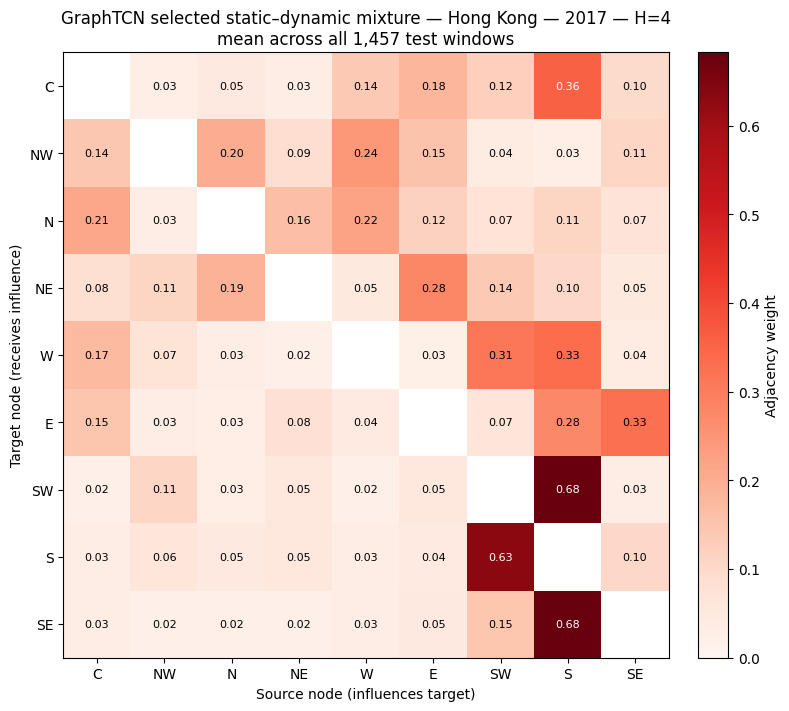

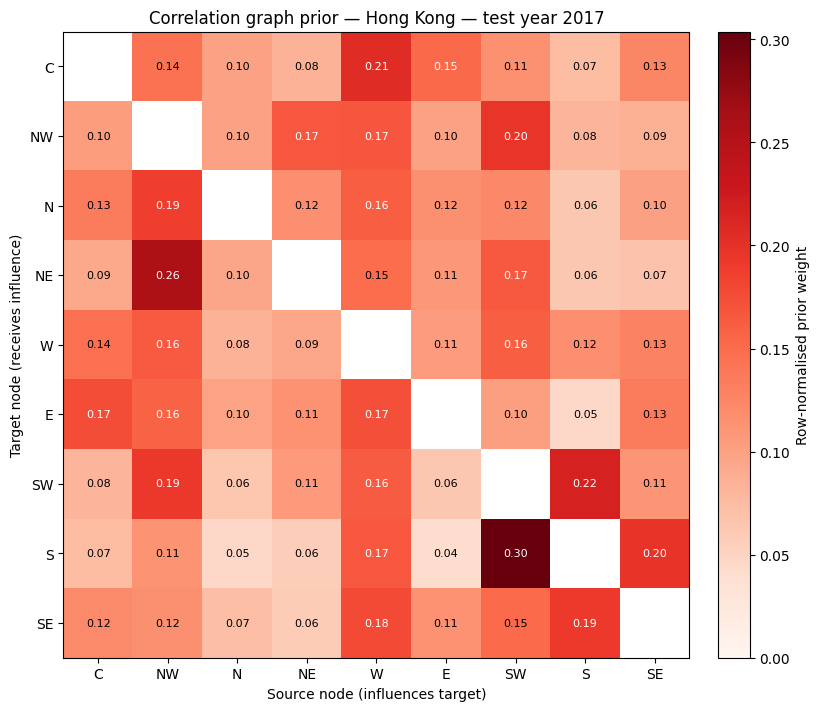

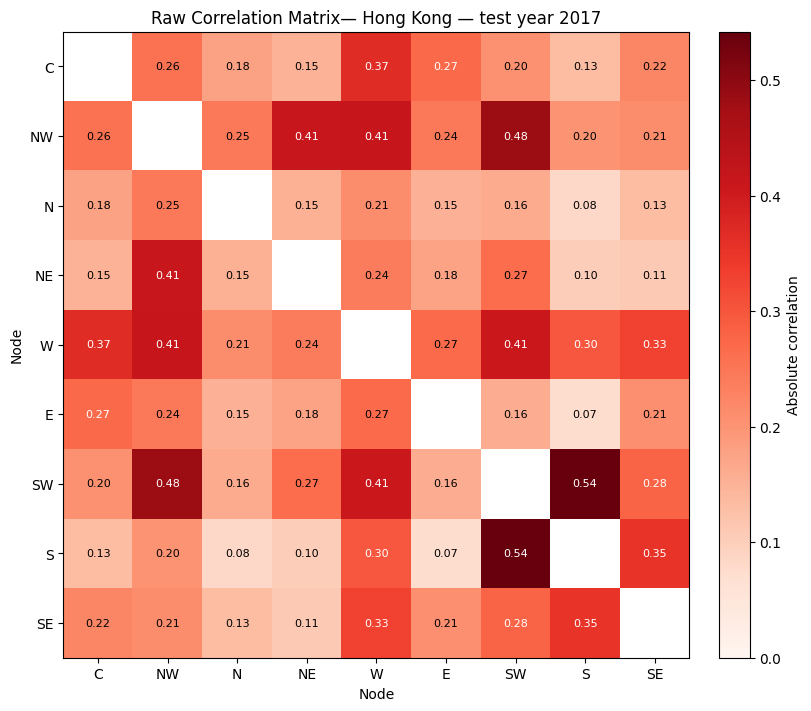

,value
city,hongkong
city_display_name,Hong Kong
test_year,2017
horizon,4
graph_component,selected
head,mean
requested_day,None
requested_window,None
selection,"mean across all 1,457 test windows"
selected_windows,1457


In [58]:
# Inputs:
# - city: city whose graph artifacts are loaded.
# - horizon: one of 4, 12, 28, or 120.
# - test_year: one of 2016, 2017, or 2018.
# - day: forecast-origin date as YYYY-MM-DD, or None.
# - window: one-based window within that day, or None.
# - graph_component: "selected", "dynamic", or "base".
(
    learned_graph_matrix,
    row_normalised_prior_matrix,
    raw_correlation_matrix,
    graph_metadata,
    learned_graph_figure,
    learned_graph_axis,
    row_normalised_prior_figure,
    row_normalised_prior_axis,
    raw_correlation_figure,
    raw_correlation_axis,
) = plot_weather_graph(
    weather_root=WEATHER_ROOT,
    city="hongkong",
    horizon=4,
    test_year=2017,
    day=None,
    window=None,
    graph_component="selected",
    annotate=True,
)

plt.show()
display(pd.Series(graph_metadata, name="value").to_frame())


## 4. Learned static--dynamic and temporal--spatial gates

For every final GraphTCN run, the table reports the learned scalar gates from the validation-selected checkpoint:

$$
A=(1-\alpha)A_{\mathrm{static}}+\alpha A_{\mathrm{dynamic}},
$$

$$
H=(1-\beta)H_{\mathrm{temporal}}+\beta H_{\mathrm{spatial}}.
$$

Rows are grouped by city, with one sub-row for each forecast horizon. Columns are grouped by the 2016, 2017, and 2018 test-year models.


In [7]:
# Input:
# - weather_root: root folder containing every completed final-transfer run.
#
# Output:
# - one table with city/horizon rows and alpha/beta columns for each test year.
alpha_beta_table = show_weather_alpha_beta_table(
    weather_root=WEATHER_ROOT,
)


## 5. Central-to-neighbour T850 correlations

This plot compares the central T850 series with each of the eight surrounding grid-point T850 series for all five cities. The supplied `test_year` selects the corresponding model training period, from 1980 through `test_year - 2`.

- `difference=False` computes ordinary Pearson correlations between the raw T850 level series.
- `difference=True` first computes six-hour T850 changes and then takes the absolute Pearson correlation, matching the source correlation matrix used to initialise the GraphTCN static prior.

The values are computed from the exported stride-one training targets, so the reconstructed series contains one observation every six hours over the exact nominal training period.


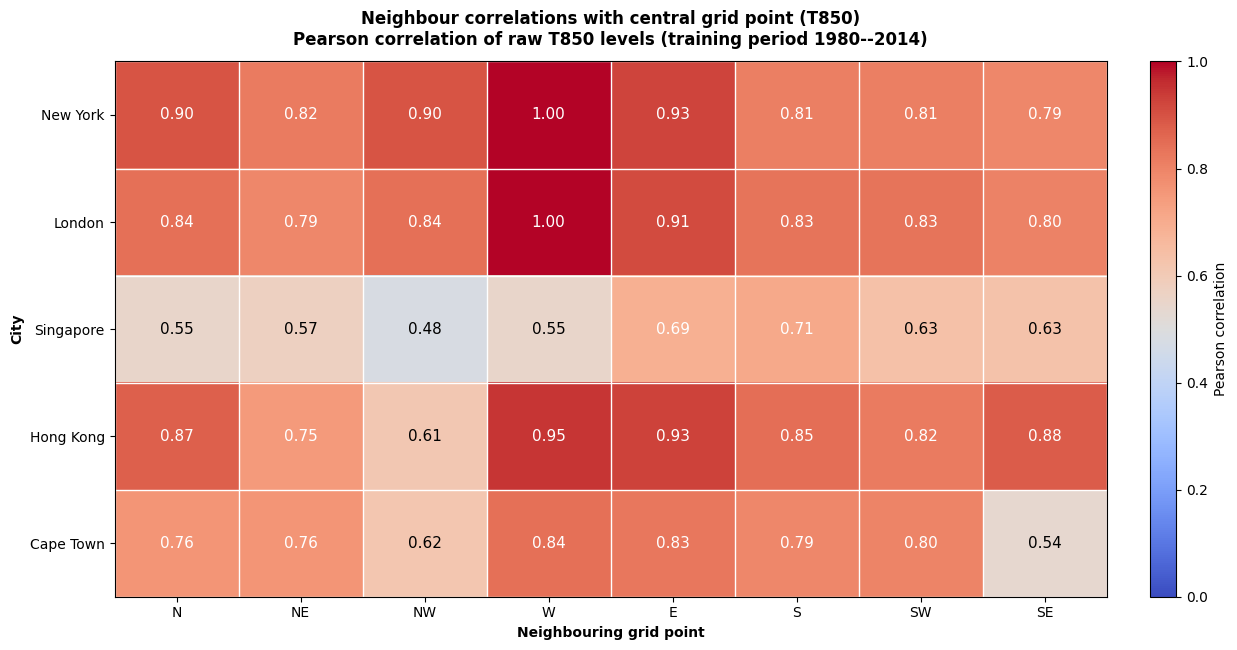

In [ ]:
# Inputs:
# - test_year: 2016, 2017, or 2018. This selects the relevant training split.
# - difference: False for raw T850 levels; True for absolute correlations
#   of six-hour T850 changes, matching the graph-prior construction.
central_neighbour_correlations, correlation_figure, correlation_axis = (
    plot_central_neighbour_t850_correlations(
        weather_root=WEATHER_ROOT,
        test_year=2016,
        difference=False,
    )
)

plt.show()
